# BLOCO DE MARLIM
Comparação das predições (`PREDICTIONS`) com a anotação do especialista na inline
central do patch. Fluxo: `Generator2.ipynb` → `../Dataset/marlim_opt/Format.ipynb`
→ treino (`../Model/Analysis.ipynb`) → `Predict.ipynb` → comparação aqui.

`FaultComparer` é a classe única de comparação: reconstrói os tiles preditos,
extrai sticks retos (`FaultStickExtractor`), plota (`show`, com `save=` para
guardar a figura) e mede a convergência com o especialista (`metrics`).

In [50]:
import os, re, json
from math import floor

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from PIL import Image
import scipy.ndimage as ndi
from tqdm import tqdm
from skimage.morphology import skeletonize

In [51]:
PATCH_METADATA = 'files/patch_metadata.json'
CACHE_DIR      = 'files/cache'
MARLIM_DIR     = '../Dataset/marlim'
MARLIM_PATCH   = f'{MARLIM_DIR}/patches_1200'
FIGURES_DIR    = 'files/comparisons'

PREDICTIONS = [
    {
        'path': 'files/patches/1200/1200_interpretado.png',
        'color': 'lime',
        'label': 'especialista'
    },
    {
        'path': '../Model/Backup/model_1/marlim/patch_1200/masks',
        'color': 'red',
        'label': 'modelo marlim_opt'
    }
]

In [52]:
def gauss(img, sigma, sigma_x=None):
    """gaussian_filter via cv2 (~10x scipy). sigma = eixo y (linhas); sigma_x opcional."""
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma if sigma_x is None else sigma_x, sigmaY=sigma,borderType=cv2.BORDER_REFLECT)


def rotate(img, angle):
    """ndi.rotate(reshape=False, order=1) via cv2.warpAffine (~20x scipy)."""
    h, w = img.shape
    M = cv2.getRotationMatrix2D(((w - 1) / 2, (h - 1) / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

# EXTRAÇÃO DE STICKS
`FaultStickExtractor` converte um mapa de probabilidade (z, x) em falhas **retas**
estilo especialista, em 4 passos: limiar adaptativo → sementes lineares (skeleton +
ajuste PCA) → crescimento ao longo da reta → fusão/aceitação/dedup.

`tolerance` (0..1) é o knob principal: 0 = conservador (só falhas longas e muito
suportadas), 1 = permissivo (aceita curtas/fracas). Qualquer limiar interno pode
ser sobrescrito por kwargs.

In [53]:
class FaultStickExtractor:
    """Converte um mapa de probabilidade (z, x) em sticks retos estilo especialista."""

    def __init__(self, tolerance=0.5, **kw):
        t = float(np.clip(tolerance, 0.0, 1.0))
        self.tolerance = t
        L = lambda a, b: a + (b - a) * t
        # ── controlados pela tolerância (0=conservador, 1=permissivo) ─────────
        self.linenessThr  = L(0.40, 0.29)  # alinhamento direcional mínimo da semente
        self.dipMin       = L(42, 36)      # dip mínimo (especialista tem rasas ~38-62°)
        self.minStickLen  = L(170, 110)    # a partir daqui vale o minFill básico
        self.minFill      = L(0.50, 0.34)  # suporte mínimo p/ sticks longos
        self.hardLen      = L(85, 50)      # comprimento mínimo absoluto (via curta)
        self.shortFill    = L(0.71, 0.50)  # fill exigido na via curta (mapa de crescimento)
        self.mergeGap     = L(50, 80)      # gap máximo p/ fundir colineares
        self.thrShift     = L(+0.04, -0.06)  # desloca o limiar adaptativo inteiro
        # ── limiar adaptativo à densidade local da predição ──────────────────
        self.thrClean     = 0.34     # limiar onde a predição é esparsa (zona limpa)
        self.thrDense     = 0.56     # limiar onde a predição é uma teia densa
        self.densSigma    = 50       # escala (px) da densidade local
        self.densRef      = 0.25     # densidade que já conta como "teia"
        self.seedBoost    = 0.06     # semente exige um pouco mais que o suporte
        # ── energia sísmica (opcional: passe seismic= no extract) ────────────
        self.energyMin    = 0.28     # energia local mínima p/ sticks CURTOS (0..1)
        self.energySigma  = 25       # escala (px) da energia local
        # ── ajuste fino (fixos) ──────────────────────────────────────────────
        self.dipMax       = 82       # especialista: dip p95 = 78° (mais que isso é artefato)
        self.growSkip     = 2        # janelas fracas puláveis (falhas reais: mediana 348 px)
        self.lowDip       = 48       # dips < isso: exigem energia e fill extra
        self.lowDipFillExtra = 0.08
        self.angleStep    = 7        # passo da varredura direcional
        self.lineLen      = 35       # comprimento do filtro direcional (px)
        self.lineWidth    = 1.5
        self.minSegLen    = 35       # comprimento mínimo do segmento semente
        self.minLinearity = 0.88
        self.growStep     = 10
        self.growWidth    = 3.0
        self.growFill     = 0.30
        self.mergeAngle   = 11.0
        self.mergeOffset  = 9.0

        for k, v in kw.items():
            setattr(self, k, v)

    # ── geometria ─────────────────────────────────────────────────────────────
    @staticmethod
    def _fit(ys, xs):
        """Ajusta uma reta (PCA) aos pontos: retorna p0, p1, dip, linearidade e comprimento."""
        pts = np.stack([xs, ys]).astype(float)
        center = pts.mean(axis=1, keepdims=True)
        pts0 = pts - center

        w, v = np.linalg.eigh(pts0 @ pts0.T / pts.shape[1])
        d = v[:, -1]
        if d[1] < 0:
            d = -d

        linearity = w[-1] / (w.sum() + 1e-9)
        t = d @ pts0
        dip = np.degrees(np.arctan2(abs(d[1]), abs(d[0]) + 1e-12))
        p0 = center[:, 0] + d * t.min()
        p1 = center[:, 0] + d * t.max()
        return p0, p1, dip, linearity, float(t.max() - t.min())

    def _corridorFill(self, supp, c, d, t0, t1):
        """Suporte médio num corredor de largura growWidth ao longo da reta (c, d)."""
        ts = np.linspace(t0, t1, max(int(abs(t1 - t0)), 1))
        offs = np.arange(-self.growWidth, self.growWidth + 0.5)
        nvec = np.array([-d[1], d[0]])
        xs = (c[0] + ts[:, None] * d[0] + offs[None, :] * nvec[0]).round().astype(int)
        ys = (c[1] + ts[:, None] * d[1] + offs[None, :] * nvec[1]).round().astype(int)
        ok = (ys >= 0) & (ys < supp.shape[0]) & (xs >= 0) & (xs < supp.shape[1])

        if not ok.any():
            return 0.0

        vals = np.zeros(xs.shape, np.float32)
        vals[ok] = supp[ys[ok], xs[ok]]
        return float(vals.max(axis=1).mean())

    # ── mapas auxiliares ──────────────────────────────────────────────────────
    def threshold_map(self, p):
        """Limiar por pixel: sobe onde a predição é uma teia densa, desce onde é limpa."""
        dens = gauss((p > 0.30).astype(np.float32), self.densSigma)
        w = np.clip(dens / self.densRef, 0, 1)
        return (self.thrClean + (self.thrDense - self.thrClean) * w
                + self.thrShift).astype(np.float32)

    def energy_map(self, seismic):
        """Energia sísmica local normalizada (0..1): onde há refletores p/ deslocar."""
        sec = seismic.astype(np.float32)
        mu = gauss(sec, self.energySigma)
        var = gauss(sec * sec, self.energySigma) - mu * mu
        E = np.sqrt(np.clip(var, 0, None))
        return np.clip(E / (np.percentile(E, 95) + 1e-9), 0, 1).astype(np.float32)

    def lineness(self, pbin):
        """Resposta máxima a filtros gaussianos alongados na faixa de dips válida."""
        sig_long = self.lineLen / 4.0
        best = np.zeros_like(pbin)

        for ang in np.arange(self.dipMin, self.dipMax + 0.1, self.angleStep):
            for sgn in (1, -1):
                a = sgn * (90 - ang)
                r = rotate(gauss(rotate(pbin, a), sig_long, self.lineWidth), -a)
                np.maximum(best, r, out=best)

        resp = best - gauss(pbin, np.sqrt(sig_long * self.lineWidth))
        return np.clip(resp / (np.percentile(resp, 99.7) + 1e-9), 0, 1.5)

    # ── sementes: componentes do skeleton quebrados em trechos retos ──────────
    def _split(self, ys, xs, depth=0):
        """Divide o componente no ponto mais distante da reta até ficar linear."""
        p0, p1, dip, lin, Ln = self._fit(ys, xs)
        if lin >= self.minLinearity or depth >= 4 or len(ys) < 2 * self.minSegLen:
            return [(ys, xs)]

        vx, vy = p1[0] - p0[0], p1[1] - p0[1]
        dist = np.abs(vy * (xs - p0[0]) - vx * (ys - p0[1])) / (np.hypot(vx, vy) + 1e-9)
        m1 = ys <= ys[int(np.argmax(dist))]
        out = []

        for m in (m1, ~m1):
            if m.sum() >= self.minSegLen:
                out += self._split(ys[m], xs[m], depth + 1)
        return out or [(ys, xs)]

    def segments(self, binary):
        """Segmentos retos candidatos: skeleton → componentes → _split → filtro dip/len."""
        lbl, n = ndi.label(skeletonize(binary), structure=np.ones((3, 3)))
        segs = []

        for i, sl in enumerate(ndi.find_objects(lbl), 1):
            if sl is None:
                continue
            ys, xs = np.nonzero(lbl[sl] == i)
            if len(ys) < self.minSegLen:
                continue

            ys, xs = ys + sl[0].start, xs + sl[1].start
            for ys2, xs2 in self._split(ys, xs):
                p0, p1, dip, lin, Ln = self._fit(ys2, xs2)
                if (Ln >= self.minSegLen and lin >= self.minLinearity
                        and self.dipMin - 4 <= dip <= self.dipMax):
                    segs.append({'p0': p0, 'p1': p1, 'dip': dip, 'len': Ln})
        return segs

    # ── crescimento ao longo da reta ──────────────────────────────────────────
    def _grow_dir(self, supp, c, d, t, sgn):
        """Avança em janelas de growStep enquanto o corredor tiver suporte
        (pode pular até growSkip janelas fracas se a seguinte for boa)."""
        skips_left = self.growSkip

        for _ in range(300):
            step = sgn * self.growStep
            fill = self._corridorFill(supp, c, d, min(t, t + step), max(t, t + step))
            if fill >= self.growFill:
                t += step
                continue

            if skips_left > 0:
                fill2 = self._corridorFill(supp, c, d, min(t + step, t + 2 * step),
                                           max(t + step, t + 2 * step))
                if fill2 >= self.growFill:
                    t += 2 * step
                    skips_left -= 1
                    continue
            break
        return t

    def grow(self, seg, supp):
        """Estende o segmento nos dois sentidos e mede o fill final do corredor."""
        p0, p1 = np.array(seg['p0']), np.array(seg['p1'])
        d = p1 - p0
        Ln = np.linalg.norm(d) + 1e-9
        d, c = d / Ln, (p0 + p1) / 2

        tmax = self._grow_dir(supp, c, d, Ln / 2, +1)
        tmin = self._grow_dir(supp, c, d, -Ln / 2, -1)

        seg = dict(seg)
        seg['p0'], seg['p1'] = tuple(c + tmin * d), tuple(c + tmax * d)
        seg['len'] = float(tmax - tmin)
        seg['fill'] = self._corridorFill(supp, c, d, tmin, tmax)
        return seg

    # ── fusão de colineares / dedup ───────────────────────────────────────────
    def _collinear(self, a, b):
        """Mesmo alinhamento, gap pequeno e offset lateral pequeno?"""
        da = np.array(a['p1']) - np.array(a['p0'])
        db = np.array(b['p1']) - np.array(b['p0'])
        da /= np.linalg.norm(da) + 1e-9
        db /= np.linalg.norm(db) + 1e-9

        if np.degrees(np.arccos(np.clip(abs(float(da @ db)), 0, 1))) > self.mergeAngle:
            return False

        ea = [np.array(a['p0']), np.array(a['p1'])]
        eb = [np.array(b['p0']), np.array(b['p1'])]
        gap = min(np.linalg.norm(x - y) for x in ea for y in eb)
        cb = (eb[0] + eb[1]) / 2
        off = abs(da[1] * (cb[0] - a['p0'][0]) - da[0] * (cb[1] - a['p0'][1]))
        return (gap <= self.mergeGap) and (off <= self.mergeOffset)

    def merge(self, segs):
        """Une grupos de segmentos colineares (union-find) numa reta só."""
        parent = list(range(len(segs)))

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        for i in range(len(segs)):
            for j in range(i + 1, len(segs)):
                if self._collinear(segs[i], segs[j]):
                    parent[find(i)] = find(j)

        groups = {}
        for i in range(len(segs)):
            groups.setdefault(find(i), []).append(i)

        out = []
        for idx in groups.values():
            pts = np.array([segs[i]['p0'] for i in idx] + [segs[i]['p1'] for i in idx])
            p0, p1, dip, lin, Ln = self._fit(pts[:, 1], pts[:, 0])
            out.append({'p0': tuple(p0), 'p1': tuple(p1), 'dip': dip, 'len': Ln})
        return out

    def _dedup(self, sticks):
        """Mantém o stick mais forte de cada grupo de colineares sobrepostos."""
        keep, used = [], [False] * len(sticks)

        for i in np.argsort([-s['fill'] * s['len'] for s in sticks]):
            if used[i]:
                continue
            used[i] = True
            keep.append(sticks[i])

            for j in range(len(sticks)):
                if used[j] or not self._collinear(sticks[i], sticks[j]):
                    continue
                ci = (np.array(sticks[i]['p0']) + np.array(sticks[i]['p1'])) / 2
                cj = (np.array(sticks[j]['p0']) + np.array(sticks[j]['p1'])) / 2
                if np.linalg.norm(ci - cj) < (sticks[i]['len'] + sticks[j]['len']) / 4:
                    used[j] = True
        return keep

    # ── aceitação ─────────────────────────────────────────────────────────────
    def _stick_energy(self, s, energy):
        p0, p1 = np.array(s['p0']), np.array(s['p1'])
        d = p1 - p0
        Ln = np.linalg.norm(d) + 1e-9
        return self._corridorFill(energy, (p0 + p1) / 2, d / Ln, -Ln / 2, Ln / 2)

    def _accept(self, s, energy):
        """Via longa (len>=minStickLen): fill no mapa conservador. Via curta
        (hardLen..minStickLen): fill alto E energia sísmica local (falha curta só é
        interpretável onde há refletores — mata os riscos da zona morta). Dips baixos
        (<lowDip) exigem energia e fill extra (crosshatch mergulha ±40-50°)."""
        if not (self.dipMin <= s['dip'] <= self.dipMax) or s['len'] < self.hardLen:
            return False

        needE = (s['len'] < self.minStickLen) or (s['dip'] < self.lowDip)
        if needE and energy is not None:
            s['energy'] = round(self._stick_energy(s, energy), 3)
            if s['energy'] < self.energyMin:
                return False

        req = self.minFill if s['len'] >= self.minStickLen else self.shortFill
        if s['dip'] < self.lowDip:
            req += self.lowDipFillExtra
        return s['fill'] >= req

    # ── pipeline ──────────────────────────────────────────────────────────────
    def extract(self, prob, seismic=None):
        """prob (z, x) em [0,1] -> sticks. seismic (opcional): seção de fundo p/ o
        gate de energia (sticks curtos precisam de refletores por perto)."""
        p = gauss(prob.astype(np.float32), 1.0)
        thr = self.threshold_map(p)
        seed = (p > thr + self.seedBoost).astype(np.float32)
        growMap = (p > thr).astype(np.float32)
        energy = self.energy_map(seismic) if seismic is not None else None

        binary = (self.lineness(seed) > self.linenessThr) \
            & ndi.binary_dilation(seed > 0, iterations=3)
        segs = self.merge([self.grow(s, growMap) for s in self.segments(binary)])

        sticks = []
        for s in segs:
            s = self.grow(s, growMap)
            if self._accept(s, energy):
                sticks.append(s)
        return self._dedup(sticks)

    def extract_volume(self, vol, axis=0, step=4):
        return {i: self.extract(np.take(vol, i, axis=axis))
                for i in tqdm(range(0, vol.shape[axis], step), desc='sticks')}

    @staticmethod
    def rasterize(sticks, shape, thickness=2):
        """Desenha os sticks numa máscara binária."""
        canvas = np.zeros(shape, np.uint8)

        for s in sticks:
            x0, y0 = s['p0']; x1, y1 = s['p1']
            n = int(max(abs(x1 - x0), abs(y1 - y0)) * 2 + 1)
            xs = np.linspace(x0, x1, n).round().astype(int)
            ys = np.linspace(y0, y1, n).round().astype(int)
            ok = (ys >= 0) & (ys < shape[0]) & (xs >= 0) & (xs < shape[1])
            canvas[ys[ok], xs[ok]] = 1

        if thickness > 1:
            canvas = ndi.binary_dilation(canvas, iterations=thickness - 1).astype(np.uint8)
        return canvas

# COMPARAÇÃO DE FALHAS
`FaultComparer` recebe o json de `PREDICTIONS` e compara tudo na inline central:

- `show(force_linear=True, tolerance=...)` → falhas **retas** via `FaultStickExtractor`
  (tolerance 0..1: 0 = só falhas longas/certas, 1 = aceita curtas/fracas);
- `show(force_linear=False, threshold=...)` → só sobrepõe a predição crua;
- `show(..., save='files/comparisons/x.png')` → salva a figura em vez de exibir;
- `metrics(tol)` → P/R/F1 com tolerância espacial + recall por falha vs especialista.

path em `PREDICTIONS`: pasta de tiles `.dat` de um modelo (reconstruída aqui dentro),
`.npy` 2D de probabilidade ou `.png` do especialista (vira a referência das métricas).
Sticks ficam cacheados por (fonte, tolerance) — trocar a tolerance no `show`
não refaz o que já foi extraído.

In [54]:
class FaultComparer:
    """Compara fontes de falha na inline central de um patch de Marlim.

    preds: lista de dicts {'path','color','label'}, onde path pode ser pasta de tiles
    .dat de um modelo, .npy 2D de probabilidade ou .png com a anotação do especialista
    (esta vira a referência das métricas). Reconstrói os tiles, extrai sticks, plota
    (show, com save=) e mede convergência (metrics) — tudo em uma classe só.
    """

    def __init__(self, metadata_path=PATCH_METADATA, img=None, preds=None, tolerance=0.35, **extractor_kw):
        self.meta  = json.load(open(metadata_path))
        self.ps    = self.meta['patch_size']
        self.ov    = self.meta['overlap_voxels']
        self.shape = tuple(self.meta['original_shape'])

        self.img_path = img
        self.preds = [dict(p) for p in (preds or [])]
        self.tolerance = tolerance
        self.extractor_kw = extractor_kw
        self._extractors, self._maps, self._sticks, self._bg = {}, {}, {}, None

    # ── reconstrução do volume a partir dos tiles .dat (com overlap) ──────────
    def _reconstruct(self, path, desc='montando'):
        """Monta o volume (64, 1601, 2240) colando o miolo de cada patch."""
        ps, ov  = self.ps, self.ov
        stride  = ps - 2 * ov
        lastIdx = [floor(n / stride) for n in self.shape]
        vol     = np.zeros(self.shape, np.float32)

        for fname in tqdm(sorted(os.listdir(path)), desc=desc):
            m = re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', fname)
            if not m:
                continue

            # origem do patch no volume (o último de cada eixo encosta na borda)
            d, h, w = [max(0, size - stride) if idx == last else idx * stride
                       for idx, last, size in zip(map(int, m.groups()), lastIdx, self.shape)]

            core = np.fromfile(os.path.join(path, fname), np.float32).reshape((ps, ps, ps))
            core = core[ov:ps - ov, ov:ps - ov, ov:ps - ov]

            cd = min(core.shape[0], self.shape[0] - d)
            ch = min(core.shape[1], self.shape[1] - h)
            cw = min(core.shape[2], self.shape[2] - w)
            vol[d:d + cd, h:h + ch, w:w + cw] = core[:cd, :ch, :cw]
        return vol

    def _center_section(self, path, desc):
        vol = self._reconstruct(self._resolve_tiles(path), desc)
        sec = vol[vol.shape[0] // 2].copy()
        del vol
        return sec

    # ── carregamento (lazy, cache em memória) ─────────────────────────────────
    @staticmethod
    def _is_annotation(p):
        return str(p['path']).lower().endswith('.png')

    def _resolve_tiles(self, path):
        for sub in ('', 'masks', 'images', 'predictions'):
            d = os.path.join(path, sub)
            if os.path.isdir(d) and any(f.startswith('patch_d') and f.endswith('.dat')
                                        for f in os.listdir(d)):
                return d
        raise FileNotFoundError(f'nenhum patch_*.dat em {path}')

    def section(self, label):
        """Mapa 2D (1601, 2240) da fonte <label>: anotação, prob .npy ou inline central."""
        if label not in self._maps:
            p = next(q for q in self.preds if q['label'] == label)
            path = str(p['path'])

            if path.endswith('.png'):
                sec = (np.array(Image.open(path).convert('L')) > 128).astype(np.float32)
            elif path.endswith('.npy'):
                sec = np.load(path).astype(np.float32)
            else:
                sec = self._center_section(path, p['label'])
            self._maps[label] = sec
        return self._maps[label]

    @property
    def background(self):
        """Sísmica da inline central (cacheada em disco em files/cache/)."""
        if self._bg is None and self.img_path:
            pid = str(self.img_path).rstrip('/').split('_')[-1]
            os.makedirs(CACHE_DIR, exist_ok=True)
            cache = os.path.join(CACHE_DIR, f'real_center_{pid}.npy')

            if os.path.exists(cache):
                self._bg = np.load(cache)
            else:
                self._bg = self._center_section(self.img_path, 'bloco')
                np.save(cache, self._bg)
        return self._bg

    def extractor(self, tolerance=None):
        t = float(self.tolerance if tolerance is None else tolerance)
        if t not in self._extractors:
            self._extractors[t] = FaultStickExtractor(tolerance=t, **self.extractor_kw)
        return self._extractors[t]

    def sticks(self, label, tolerance=None):
        t = float(self.tolerance if tolerance is None else tolerance)
        key = (label, t)
        if key not in self._sticks:
            self._sticks[key] = self.extractor(t).extract(self.section(label),
                                                          seismic=self.background)
        return self._sticks[key]

    # ── visualização ──────────────────────────────────────────────────────────
    def show(self, force_linear=True, tolerance=None, threshold=0.5, alpha=0.65,
             figsize=(15, 9), save=None):
        """Plota a comparação; save='caminho.png' grava a figura em vez de exibir."""
        fig, ax = plt.subplots(figsize=figsize)
        bg = self.background
        ax.imshow(bg if bg is not None else np.zeros(self.shape[1:]),
                  cmap='gray', aspect='auto')
        handles = []

        for p in self.preds:
            color = to_rgb(p['color'])

            if self._is_annotation(p):                    # anotação: sempre como está
                gy, gx = np.where(self.section(p['label']) > 0.5)
                ax.scatter(gx, gy, s=0.05, c=[color], alpha=0.8)
            elif force_linear:                            # sticks retos
                for s in self.sticks(p['label'], tolerance):
                    ax.plot([s['p0'][0], s['p1'][0]], [s['p0'][1], s['p1'][1]],
                            color=color, lw=1.6)
            else:                                         # predição crua com threshold
                m = self.section(p['label']) >= threshold
                rgba = np.zeros((*m.shape, 4), np.float32)
                rgba[..., :3] = color
                rgba[..., 3] = m * alpha
                ax.imshow(rgba, aspect='auto')
            handles.append(Patch(facecolor=color, label=p['label']))

        mode = f'sticks (force_linear, tolerance={self.extractor(tolerance).tolerance})' \
            if force_linear else f'threshold {threshold}'
        ax.set_title(f'comparação de falhas — {mode}')
        ax.legend(handles=handles, loc='upper right', framealpha=0.9)
        plt.tight_layout()

        if save:
            os.makedirs(os.path.dirname(save) or '.', exist_ok=True)
            plt.savefig(save, dpi=200, bbox_inches='tight')
            plt.close(fig)
            return print(f'figura salva em {save}')

        plt.show()
        return ax

    # ── métricas ──────────────────────────────────────────────────────────────
    @staticmethod
    def _stick_metrics(pred_mask, gt_mask, tol=10):
        """Precisão/recall pixel a pixel com tolerância espacial (px)."""
        if pred_mask.sum() == 0:
            return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

        gt_d = ndi.binary_dilation(gt_mask, iterations=tol)
        pr_d = ndi.binary_dilation(pred_mask, iterations=tol)
        prec = float(pred_mask[gt_d].sum()) / float(pred_mask.sum())
        rec = float(gt_mask[pr_d].sum()) / float(gt_mask.sum() + 1e-9)
        return {'precision': round(prec, 3), 'recall': round(rec, 3),
                'f1': round(2 * prec * rec / (prec + rec + 1e-9), 3)}

    @staticmethod
    def _fault_level_metrics(sticks, gt, tol=10, min_px=25):
        """Métricas por FALHA: fração das falhas do especialista cobertas (>=50% do
        traço a <=tol px de algum stick) e fração de sticks numa falha anotada."""
        raster = FaultStickExtractor.rasterize(sticks, gt.shape, thickness=1)
        pr_d = ndi.binary_dilation(raster, iterations=tol)
        gt_d = ndi.binary_dilation(gt, iterations=tol)
        lbl, n = ndi.label(gt, structure=np.ones((3, 3)))
        matched, total = 0, 0

        for i in range(1, n + 1):
            ys, xs = np.where(lbl == i)
            if len(ys) < min_px:
                continue
            total += 1
            matched += pr_d[ys, xs].mean() >= 0.5

        sp = 0
        for s in sticks:
            r1 = FaultStickExtractor.rasterize([s], gt.shape, thickness=1)
            ys, xs = np.where(r1)
            if len(ys) and gt_d[ys, xs].mean() >= 0.5:
                sp += 1

        return {'fault_recall': round(matched / max(total, 1), 3),
                'stick_precision': round(sp / max(len(sticks), 1), 3),
                'n_faults_gt': total, 'n_sticks': len(sticks)}

    def metrics(self, ref=None, tol=10, tolerance=None, threshold=0.5, linear=True):
        """P/R/F1 por pixel + recall por falha (tolerância em px) vs a anotação.
        A anotação do especialista é PARCIAL (só as falhas principais): recall_falhas
        é a métrica confiável; precisão vs especialista é limite inferior."""
        ref = ref or next((p['label'] for p in self.preds if self._is_annotation(p)), None)
        assert ref, 'nenhuma anotação (.png) em preds — passe ref=<label>'
        gt = self.section(ref) > 0.5
        rows = []

        for p in self.preds:
            if p['label'] == ref:
                continue
            raw = self._stick_metrics((self.section(p['label']) >= threshold).astype(np.uint8), gt, tol)
            row = {'fonte': p['label'],
                   'P_bruto': raw['precision'], 'R_bruto': raw['recall'], 'F1_bruto': raw['f1']}

            if linear:
                sticks = self.sticks(p['label'], tolerance)
                stk = FaultStickExtractor.rasterize(sticks, gt.shape, thickness=3)
                lin = self._stick_metrics(stk, gt, tol)
                fl = self._fault_level_metrics(sticks, gt, tol)
                row.update({'P_sticks': lin['precision'], 'R_sticks': lin['recall'],
                            'F1_sticks': lin['f1'],
                            'recall_falhas': fl['fault_recall'],
                            'prec_sticks': fl['stick_precision'],
                            'n_sticks': fl['n_sticks']})
            rows.append(row)

        print(f'referência: {ref} | tolerância: {tol}px | threshold: {threshold} | '
              f'tolerance extractor: {self.extractor(tolerance).tolerance}')
        return pd.DataFrame(rows)

modelo marlim_opt: 100%|██████████| 910/910 [00:01<00:00, 750.39it/s]


figura salva em files/comparisons/1200_bruto.png


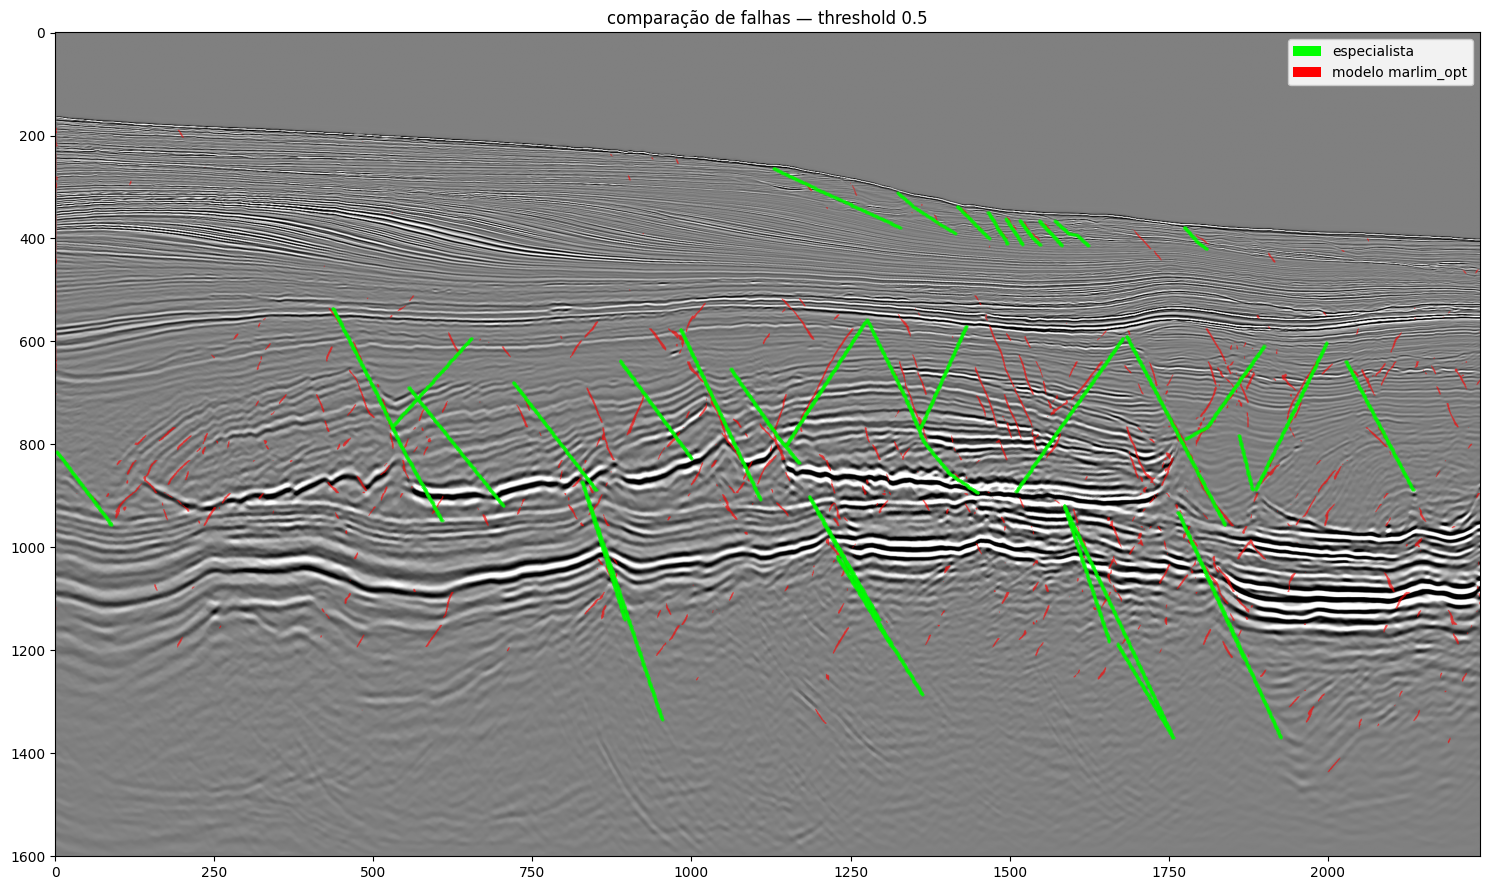

<Axes: title={'center': 'comparação de falhas — threshold 0.5'}>

In [55]:
comparer = FaultComparer(img=MARLIM_PATCH, preds=PREDICTIONS)
comparer.show(force_linear=False, threshold=0.5, save=f'{FIGURES_DIR}/1200_bruto.png')
comparer.show(force_linear=False, threshold=0.5)

figura salva em files/comparisons/1200_sticks.png


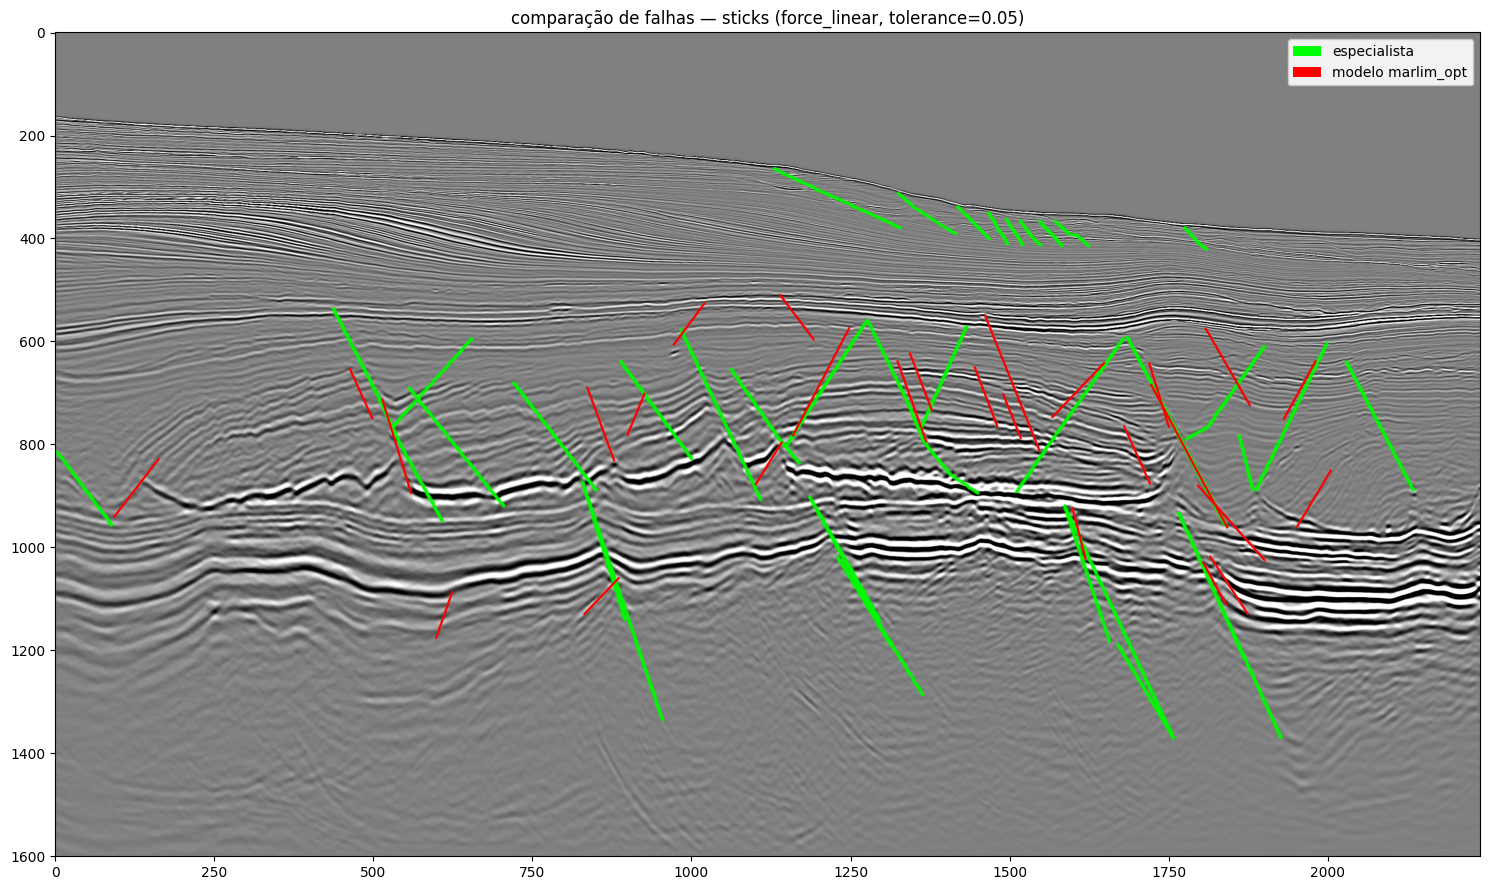

<Axes: title={'center': 'comparação de falhas — sticks (force_linear, tolerance=0.05)'}>

In [56]:
comparer.show(force_linear=True, tolerance=0.05, save=f'{FIGURES_DIR}/1200_sticks.png')
comparer.show(force_linear=True, tolerance=0.05)

# MÉTRICAS
Convergência com o especialista (tol em pixels): `*_bruto` usa a predição com threshold,
`*_sticks` usa as falhas retas; `recall_falhas` = fração das falhas anotadas cobertas,
`prec_sticks` = fração dos sticks que caem numa falha anotada. **A anotação é parcial
(só as falhas principais)** — priorize `recall_falhas`; a precisão é limite inferior.

In [57]:
comparer.metrics(tol=10, tolerance=0.10)

referência: especialista | tolerância: 10px | threshold: 0.5 | tolerance extractor: 0.1


,fonte,P_bruto,R_bruto,F1_bruto,P_sticks,R_sticks,F1_sticks,recall_falhas,prec_sticks,n_sticks
0,modelo marlim_opt,0.241,0.444,0.312,0.339,0.158,0.216,0.04,0.269,26
